In [1]:
# Phase 1: Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Display Settings
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# Phase 2: Load Dataset

# Load the dataset
df = pd.read_excel("../datasets/Telco_customer_churn.xlsx")

print("Dataset Loaded Successfully!\n")

# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Display dataset dimensions
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

In [ ]:

# Phase 3.1: Dataset Overview

# Display dataset information
print("Dataset Information:\n")
df.info()

# Display data types
print("\nData Types:\n")
display(df.dtypes)

# Display dataset dimensions
print("\nDataset Shape:")
print(df.shape)

# Phase 3.2: Missing Values & Duplicates

# Missing values
missing_values = df.isnull().sum()

print("Missing Values:\n")
display(missing_values[missing_values > 0])

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Phase 3.3: Statistical Summary

print("Numerical Summary:")
display(df.describe())

print("\nCategorical Summary:")
display(df.describe(include='object'))

# Phase 3.4: Target Variable Distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Churn Label")
plt.title("Churn by Gender")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn Label")
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Internet Service", hue="Churn Label")
plt.title("Churn by Internet Service")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn Label", y="Monthly Charges")
plt.title("Monthly Charges vs Churn")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn Label", y="Tenure Months")
plt.title("Tenure Months vs Churn")
plt.show()

In [ ]:
# Phase 4: Data Preprocessing
# Create a copy of the dataset
df_processed = df.copy()

# Step 1: Remove Unnecessary Columns

columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",

    # Target Leakage Columns
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

df_processed.drop(columns=columns_to_drop, inplace=True)
print("Unnecessary columns removed successfully!")

# Step 2: Encode Target Variable

df_processed["Churn Label"] = df_processed["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

print("\nTarget Variable Encoded Successfully!")

# Step 3: Convert Total Charges to Numeric
df_processed["Total Charges"] = pd.to_numeric(
    df_processed["Total Charges"],
    errors="coerce"
)

# Fill missing values (if any)
df_processed["Total Charges"] = df_processed["Total Charges"].fillna(
    df_processed["Total Charges"].median()
)

print("\n'Total Charges' converted to numeric.")

# Step 4: Encode Categorical Features
label_encoder = LabelEncoder()

categorical_columns = df_processed.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    df_processed[column] = label_encoder.fit_transform(df_processed[column])

print("\nCategorical Features Encoded Successfully!")

# Step 5: Verify Dataset
print("\nRemaining Data Types:\n")
display(df_processed.dtypes)

print("\nMissing Values:")
print(df_processed.isnull().sum().sum())

print("\nDataset Shape:")
print(df_processed.shape)

display(df_processed.head())

In [6]:
# Phase 5: Train-Test Split
# Separate features (X) and target (y)
X = df_processed.drop("Churn Label", axis=1)
y = df_processed["Churn Label"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display dataset shapes
print("Training Feature Set :", X_train.shape)
print("Testing Feature Set  :", X_test.shape)

print("\nTraining Target Set  :", y_train.shape)
print("Testing Target Set   :", y_test.shape)

# Display class distribution
print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Feature Set : (5634, 20)
Testing Feature Set  : (1409, 20)

Training Target Set  : (5634,)
Testing Target Set   : (1409,)

Training Class Distribution:
Churn Label
0    4139
1    1495
Name: count, dtype: int64

Testing Class Distribution:
Churn Label
0    1035
1     374
Name: count, dtype: int64


In [7]:
# Phase 6: Build and Train Decision Tree Model

# Create the Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)
print("Decision Tree Model Trained Successfully!")
print("Tree Depth :", dt_model.get_depth())
print("Number of Leaf Nodes :", dt_model.get_n_leaves())

Decision Tree Model Trained Successfully!
Tree Depth : 28
Number of Leaf Nodes : 966


In [8]:
# Phase 7: Model Prediction

# Predict the target values for the test set
y_pred = dt_model.predict(X_test)

print("Predictions Generated Successfully!")

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(comparison.head(10))

Predictions Generated Successfully!


,Actual,Predicted
0,0,0
1,0,1
2,0,0
3,0,1
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,1,0


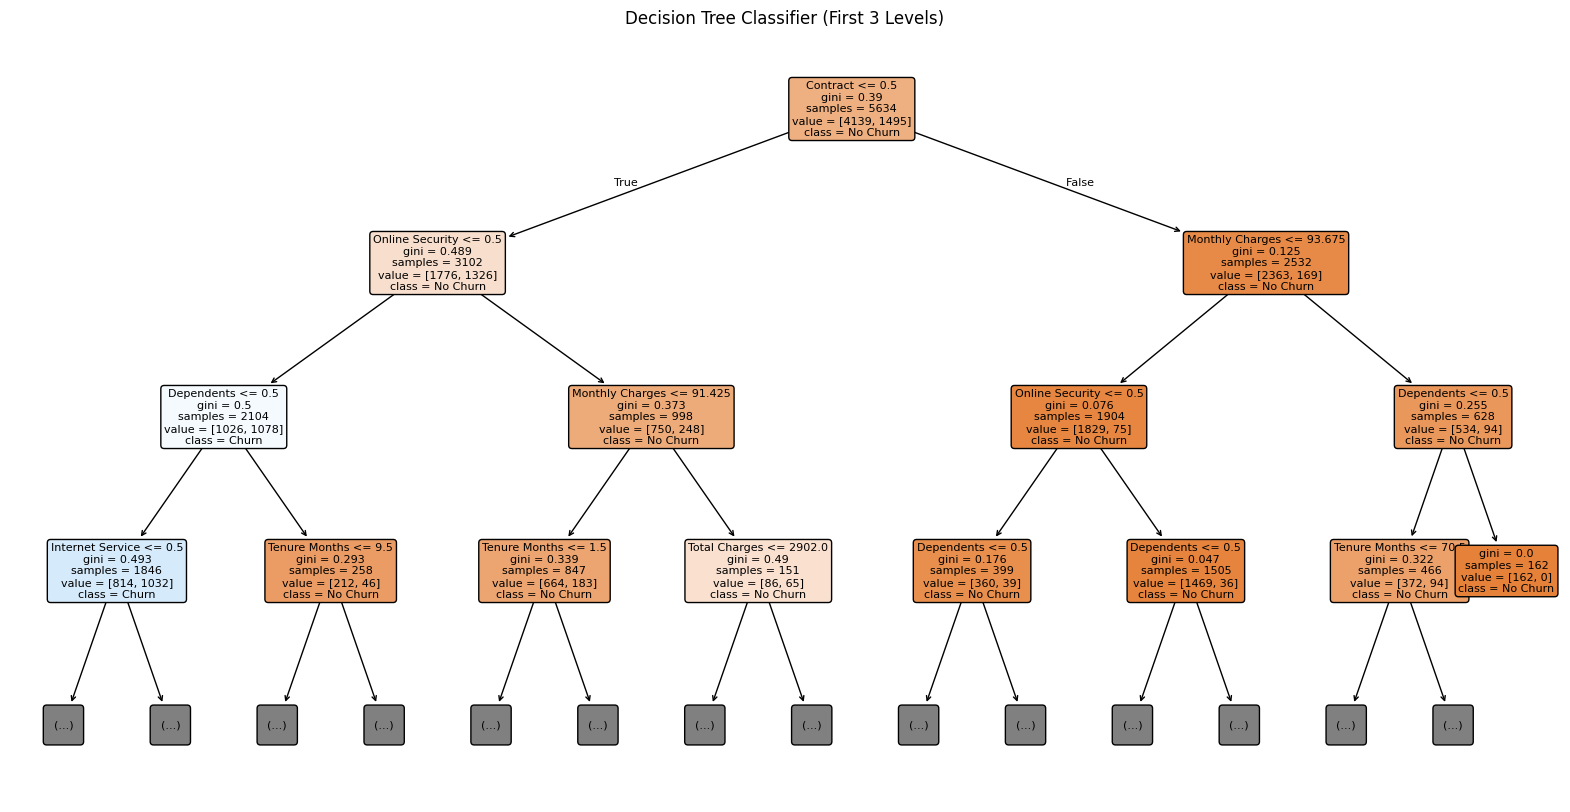

In [9]:
# Phase 8: Decision Tree Visualization

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Decision Tree Classifier (First 3 Levels)")

plt.show()

Model Performance
----------------------------------------
Accuracy : 0.7289
Precision: 0.4894
Recall   : 0.4920
F1-Score : 0.4907


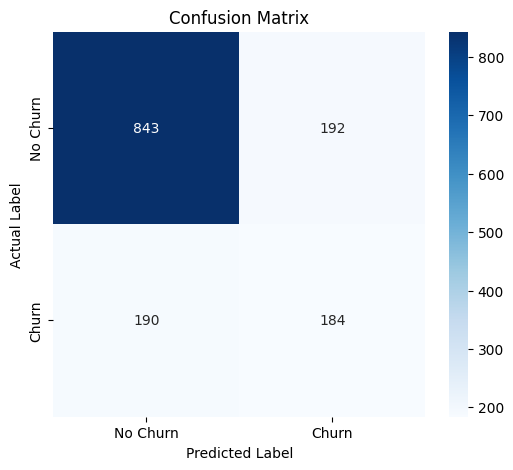

Classification Report
----------------------------------------
              precision    recall  f1-score   support

    No Churn       0.82      0.81      0.82      1035
       Churn       0.49      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [10]:
# Phase 9.1: Performance Metrics

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
# Phase 9.2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()
# Phase 9.3: Classification Report
print("Classification Report")
print("-" * 40)

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))